# Day 009 · 线性回归与最小二乘 · 中国版
**OLS & Linear Regression** · 阶段 P1 · 量化基础

> 线性回归是量化里最最最基础的工具,没有之一。说人话:在一堆乱糟糟的散点里画一根棍子,让它尽量贴着所有的点。把工商银行每天涨跌画在竖轴,沪深三百当天涨跌画在横轴,跑三年下来七百多个点散在纸上,你画一根最贴的棍子穿过去——这根棍子的斜率就是大名鼎鼎的'贝塔',告诉你这只票跟市场跑得有多紧。截距叫'阿尔法',告诉你这只票自己有多大本事。决定系数 R² 告诉你这根棍子能解释多少波动。这一节用工商银行(低贝塔)、隆基绿能(中高贝塔)、英伟达(高贝塔)三只完全不同性格的标的,一次把 OLS / α / β / R² / 残差 / 市场中性策略全部讲透。学完你能算出自家股票的贝塔,看清它是个跟市场跑的乖孩子还是有自己脾气的特立独行者。

---

### 关于「中国版」

本 notebook 是为**国内学员**优化的版本:
- 数据源用 **akshare**(国内可访问、零 VPN、免注册),取代了视频里的 yfinance
- 标的尽量保持原意:美股 ETF→A 股 ETF / 国际公司→A 股龙头
- 所讲的**概念和方法 100% 一致**,但**具体数字可能与视频里略有差异**(因为是不同时间窗 / 不同标的)
- 一般情况国内 `pip install akshare` 即可,无需 token / VPN

**课件生成日期:** 2026-05-04  ·  **建议学习时长:** 18 分钟

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有必需的 Python 包(含 `akshare`),缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续


In [6]:
# === 环境自检 + 自动安装(运行此单元格即可)===
import importlib, subprocess, sys, os

REQUIRED = ["akshare", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels"]
PIP_NAME = {"sklearn":"scikit-learn","cv2":"opencv-python","PIL":"Pillow","bs4":"beautifulsoup4","yaml":"PyYAML"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))
if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置 ===
import matplotlib, matplotlib.pyplot as plt, matplotlib.font_manager as fm
CJK = ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
       "C:/Windows/Fonts/msyh.ttc","C:/Windows/Fonts/simhei.ttf",
       "/System/Library/Fonts/PingFang.ttc","/System/Library/Fonts/STHeiti Medium.ttc"]
for p in CJK:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP","Microsoft YaHei","PingFang SC","SimHei","DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪


## 🔌 第二步:加载国内数据助手

下面这一格是**工具函数**(可以折叠,不需要修改)。它把 `yfinance` 风格的 ticker(如 `600519.SS`)自动路由到对应的 akshare 接口,提供 `get_close(ticker)` 和 `get_close_multi(tickers_dict)` 两个函数。

In [7]:
# === 国内数据源助手(akshare 后端,不需要 VPN)===
# 这一格是工具函数,可以折叠,不需要修改。
# 它把 yfinance 风格的 ticker(如 "600519.SS" / "0700.HK" / "AAPL" / "BTC-USD")
# 自动路由到对应的 akshare 接口,统一返回 yfinance 风格的 Close DataFrame。

import re
from datetime import datetime, timedelta
import pandas as pd
import akshare as ak

_TICKER_MAP = {
    "^GSPC": ("us_index_sina", ".INX"),
    "^DJI":  ("us_index_sina", ".DJI"),
    "^IXIC": ("us_index_sina", ".IXIC"),
    "GC=F":  ("foreign_futures", "GC"),
    "SI=F":  ("foreign_futures", "SI"),
    "CL=F":  ("foreign_futures", "CL"),
    "BTC-USD": ("crypto", "BTC"),
    "ETH-USD": ("crypto", "ETH"),
}

def _parse_period(period):
    end = datetime.today()
    m = re.match(r"^(\d+)\s*(y|mo|d|w)$", period.lower().strip())
    days = 365 * 3 if not m else int(m.group(1)) * {"y":365,"mo":30,"w":7,"d":1}[m.group(2)]
    return (end - timedelta(days=days+30)).strftime("%Y%m%d"), end.strftime("%Y%m%d")

def _classify(ticker):
    t = ticker.strip()
    if t in _TICKER_MAP: return _TICKER_MAP[t]
    if t.endswith((".SS",".SH",".SZ")):
        code = t.split(".")[0]
        if code.startswith(("51","159","58")) or code in ("510300","510500","510050","511010","513100"):
            return ("a_etf", code)
        if code in ("000300","000016","000905","000852","000001"):
            return ("a_index", code)
        return ("a_stock", code)
    if t.endswith(".HK"):
        return ("hk", t.split(".")[0].zfill(5))
    return ("us", t)

def _norm(df, dc, cc):
    out = df[[dc, cc]].copy()
    out[dc] = pd.to_datetime(out[dc])
    return out.set_index(dc).sort_index()[cc].astype(float).rename("Close")

def get_close(ticker, period="3y"):
    """返回某标的 Close 价格 series。后端 akshare,中国可访问。"""
    start, end = _parse_period(period)
    kind, sym = _classify(ticker)
    if kind == "a_stock":
        return _norm(ak.stock_zh_a_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_etf":
        return _norm(ak.fund_etf_hist_em(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_index":
        idx_map = {"000300":"sh000300","000016":"sh000016","000905":"sh000905","000852":"sh000852","000001":"sh000001"}
        s = _norm(ak.stock_zh_index_daily_em(symbol=idx_map.get(sym, f"sh{sym}")), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "hk":
        return _norm(ak.stock_hk_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "us":
        # 美股走新浪源(stock_us_daily 直接吃 NVDA / AAPL 裸 symbol;stock_us_hist 要带前缀)
        s = _norm(ak.stock_us_daily(symbol=sym, adjust="qfq"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "us_index_sina":
        s = _norm(ak.index_us_stock_sina(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "foreign_futures":
        s = _norm(ak.futures_foreign_hist(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "crypto":
        # akshare 没稳定的 crypto_hist(2026-05 已移除/改名)。
        # 直接调 Binance 公共 API,国内可访问、无需 SDK。
        import requests as _rq
        r = _rq.get("https://api.binance.com/api/v3/klines",
                    params={"symbol": f"{sym}USDT", "interval": "1d", "limit": 1000}, timeout=15)
        r.raise_for_status()
        df = pd.DataFrame(r.json(), columns=["open_time","open","high","low","close","volume",
                                              "close_time","qav","trades","tbb","tbq","ignore"])
        df["date"] = pd.to_datetime(df["open_time"], unit="ms")
        df["close"] = df["close"].astype(float)
        s = df.set_index("date").sort_index()["close"].rename("Close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    raise ValueError(f"unsupported ticker: {ticker}")

def get_close_multi(tickers, period="3y"):
    """批量取 Close,返回 DataFrame,列名是 tickers dict 的 key(中文名),按交集日期对齐。"""
    series = {name: get_close(t, period=period) for name, t in tickers.items()}
    return pd.concat(series, axis=1).sort_index()

print("✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据")


✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据


## 学习目标

- 理解散点图 + '最贴的线'的直觉,把抽象的'回归'落地为画图问题
- 看懂最小二乘(OLS)为什么用平方而不是绝对值,以及它的两个数学好处
- 掌握贝塔(β)、阿尔法(α)、决定系数(R²)在金融里的精确含义和典型量级
- 学会用残差识别超额收益信号 — 整个统计套利策略的起点
- 知道线性回归的四个常见坑(样本太少 / 贝塔漂移 / R² 标准 / 数据脏)
- 理解市场中性策略 = 用 β 对冲市场风险,只留 α — 私募里的核心打法

## 历史背景:Galton、Fama 和散户最常踩的'我以为我选错了'误判

1885 年 Francis Galton 研究'父亲身高 vs 儿子身高'时,把数据画成散点图,发现高个子父亲的儿子虽然也偏高,但平均会向'整体均值'回归——他造了'回归'(regression)这个词,本意是'回到均值'。后来 Karl Pearson、R.A. Fisher 把它形式化成今天的最小二乘回归(OLS)。

1964 年 William Sharpe 提出 CAPM(资本资产定价模型),核心就是把单只股票收益对市场收益做线性回归,斜率叫贝塔,截距叫阿尔法。Sharpe 因此 1990 年和 Markowitz 一起拿了诺贝尔奖。1973 年 Black-Scholes-Merton 期权公式发表;1992 年 Fama-French 三因子模型把贝塔扩展到三个维度——这一切的源头,都是这条最朴素的'最贴的线'。

回到散户场景。一波大跌下来,你账户跌 3.2%,半夜睡不着以为自己选错了股。其实你打开沪深三百一看,大盘当天跌 3%,你那只股票贝塔 1.05,跌 3.2% 完全在数学预测之内——你不是选错了股,你只是没算自己买的股票贝塔。

整个公募私募行业每天加班加点干的一件事,就是找'正阿尔法'——扣掉跟市场跑那部分,你这只股票自己创造的超额收益。一个基金经理能稳定做出年化 5% 阿尔法,在业内就是顶级。

本节最重要的两句话:**贝塔是市场敏感度,阿尔法是真本事**;**残差是量化选股最朴素也最强的信号源**。

**关键人物:**
- Francis Galton(1885,'回归'一词的创造者)
- Karl Pearson(把回归形式化成数学公式)
- William Sharpe(1964,CAPM 模型,贝塔/阿尔法在金融里的命名)
- Eugene Fama & Kenneth French(1992,三因子模型,把单贝塔扩展到 size + value)
- Carl Friedrich Gauss(最小二乘法的奠基,1809 年用来算行星轨道)

## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 散点图 + '最贴的线':直觉先行

想象你测一百个成年男性的身高和体重,在纸上每人点一个点。眯着眼一看,大致从左下到右上排——身高高的体重也大。你想画一根棍子穿过这群点,让它告诉你'身高每多 10cm,体重平均多几公斤'。这就是回归。

金融场景:横轴 = 沪深三百当天涨跌,竖轴 = 工商银行当天涨跌,每天一个点,三年 700+ 个点。你画一根最贴的棍子,斜率告诉你'沪深三百每涨 1%,工行平均涨多少'。这个数就是工行的贝塔。

'最贴'怎么定义?所有点到棍子的垂直距离平方和最小——这就是最小二乘(OLS, Ordinary Least Squares)。

```
y = α + β·x + ε,    最小化 Σ(y_i - α - β·x_i)²
```

> **举例:** 工行三年日数据约 730 个点对沪深三百回归,得到 β ≈ 0.7,α ≈ 0.0001。意思是沪深三百涨 1% 时,工行平均涨 0.7% + 万分之一(几乎可忽略)。


### 2. 为什么用平方,不用绝对值?

为什么距离要平方求和,而不是直接取绝对值?两个原因:

**① 数学上更干净**。绝对值函数在 0 处不光滑,要求最小值得用迭代算法(梯度下降),很慢。平方函数处处可导,我们可以写出闭式解(closed-form),一步算出最优 α 和 β。

**② 大偏离被强烈惩罚**。点偏离 2 → 平方贡献 4;偏离 4 → 平方贡献 16。远点对线的拉力是近点的 4 倍,模型不会忽视极端点,会努力靠过去。

代价:OLS 对极端值过于敏感。一只股票里一两个极端日(财报暴雷 / 涨跌停)能把斜率拉偏。实战要做异常值清洗(去掉 ±5σ 之外的天)或用稳健回归(robust regression、Huber loss)。

```
L2 损失:Σ(y_i - ŷ_i)²    vs    L1 损失:Σ|y_i - ŷ_i|
```

> **举例:** 金融实践:对正常日用 OLS;对加密 / 小盘股这种极端值多的标的,优先用 Huber 回归或先剪 winsorize。


### 3. 贝塔(β):五种性格 vs 市场

贝塔告诉你:市场涨 1% 时,你这只股票平均涨多少。下面五种贝塔人格化解释。

实战意义:① 进攻型选 β > 1 高弹性;② 防守型选 β < 1 低弹性;③ 加权账户总贝塔决定整体市场风险敞口。

| 贝塔范围 | 别称 | 含义 | 典型代表 |
| --- | --- | --- | --- |
| β = 1.0 | 市场复印件 | 涨跌跟大市完全同步 | 沪深三百 ETF |
| β = 0.5-0.8 | 温和版 | 市场涨 1 它涨 0.5-0.8 | 大银行(工行 0.7) / 公用事业 / 消费必需 |
| β = 1.2-1.5 | 加强版 | 涨跌都被放大 | 科技股(隆基绿能 1.4) / 券商 / 地产 |
| β > 1.5 | 放大镜 | 极高弹性 | 小盘成长股 / AI 概念(英伟达对标普 1.9) / 高贝塔创业板 |
| β < 0 | 反向 | 市场涨它跌、市场跌它涨 | 黄金某些时段 / 避险资产 / 做空 ETF |

```
β = Cov(R_股, R_市场) / Var(R_市场)
```

> **举例:** 工行(β=0.7) + 隆基(β=1.4) + 英伟达(β=1.9) 等权组合,组合贝塔 = (0.7+1.4+1.9)/3 ≈ 1.33。市场跌 10% 时,组合理论上跌 13.3%。


### 4. 阿尔法(α):基金经理一辈子追的圣杯

阿尔法是回归方程的截距,告诉你:扣掉跟市场跑的那部分以后,你这只股票自己有多大本事。


- **α > 0 → 跑赢市场**:(超额收益)。如果是日数据,α=0.0002 ≈ 年化 5%(乘 252)——这在业内是顶级。
- **α = 0 → 跟市场一致**:(只是市场敞口的产物,自己没贡献)。
- **α < 0 → 跑输市场**:(还不如直接买指数)。


整个公募私募行业每天的核心工作就是找正阿尔法。能稳定做出年化 5% 阿尔法的基金经理,业内已经是顶级。

阿尔法的统计显著性:你算出 α=5%/年,但它带误差。专业人士看 α / SE(α) 是否 > 2(t-stat),大于 2 才说'阿尔法显著不为零';小于 2 这 5% 可能纯靠运气,下个周期就没了。学术界鉴定基金经理真水平 vs 运气,核心看这个比值。

```
α = R̄_股 - β · R̄_市场,  t-stat = α / SE(α)
```

> **举例:** 某私募近 3 年阿尔法 +6%/年,t-stat = 2.5(显著)→ 真有水平。另一只阿尔法 +8%/年,t-stat = 1.2(不显著)→ 8% 大概率是运气,不要追。


### 5. 决定系数(R²)+ 残差 + 市场中性策略

**R² 是 0-1 之间的'解释百分比'**。R²=0.8 意思是'回归线能解释 80% 的波动,剩下 20% 是别的因素'。

金融里 R² 量级:工行对沪深三百 R²≈0.65(银行业跟大市绑很紧);隆基对沪深三百 R²≈0.35(还有光伏 / 政策 / 上游硅料各种自己故事);英伟达对标普 R²≈0.45(一半是自己的 AI 叙事)。

**残差 = 实际值 - 预测值**,是量化选股最朴素的信号。某天沪深三百跌 1%,工行 β=0.7 模型预测它跌 0.7%,实际只跌 0.3%——残差 +0.4%,意思是工行今天跑赢大市 0.4%。

如果一只股票连续多天残差都是正的,说明扣掉市场原因后还在源源不断创超额收益——这就是统计套利的起点。把全市场所有股票按残差排序,买正残差、卖负残差,就是最朴素的统计套利策略。

**市场中性策略**:你买 100 万隆基(β=1.4),理论市场风险 = 100×1.4 = 140 万。卖空 140 万沪深三百股指期货,市场涨跌部分被对冲,只留下隆基的纯阿尔法——这是私募里最经典的中性打法。

```
R² = 1 - SS_residual/SS_total    残差 ε_i = y_i - (α + β·x_i)
```

> **举例:** 市场中性实操:买 100 万隆基(β=1.4)+ 卖空 140 万 IF 期货。如果市场跌 5%,多头亏 5×1.4 = 7 万,空头赚 5%×1.4 = 7 万,完美对冲。净盈亏 = 隆基的纯阿尔法(可能 +1.5%/月,扣掉融券 / 期货成本约 0.3%/月,净 1.2%/月)。


## 实操:线性回归 + 贝塔/阿尔法/R 方实战

下面这段代码用 akshare 抓数据,国内零 VPN 跑通。**直接 Run All** 看结果。

**依赖:** `pip install pandas numpy matplotlib akshare statsmodels scipy`

/tmp/ipykernel_212712/2213036073.py:89: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(series, axis=1).sort_index()


A 股样本: 742 天 / 美股样本: 770 天
=== A 股标的 vs 沪深三百 ===
工商银行 vs 沪深三百:
  贝塔 β = +0.182
  阿尔法(日) α = +0.1063% / 年化 ≈ +26.80%
  决定系数 R² = 0.023

隆基绿能 vs 沪深三百:
  贝塔 β = +1.436
  阿尔法(日) α = -0.1275% / 年化 ≈ -32.12%
  决定系数 R² = 0.392

=== 美股 vs 标普五百 ===
英伟达 vs 标普五百:
  贝塔 β = +2.118
  阿尔法(日) α = +0.1405% / 年化 ≈ +35.41%
  决定系数 R² = 0.420

✓ 图已保存到 day009_regression.png

=== 工行最近 5 天残差(跑赢/输大市) ===
  2026-04-24: 残差 -0.042% (跑输 大市 0.042%)
  2026-04-27: 残差 -1.036% (跑输 大市 1.036%)
  2026-04-28: 残差 +0.209% (跑赢 大市 0.209%)
  2026-04-29: 残差 -1.103% (跑输 大市 1.103%)
  2026-04-30: 残差 -0.363% (跑输 大市 0.363%)


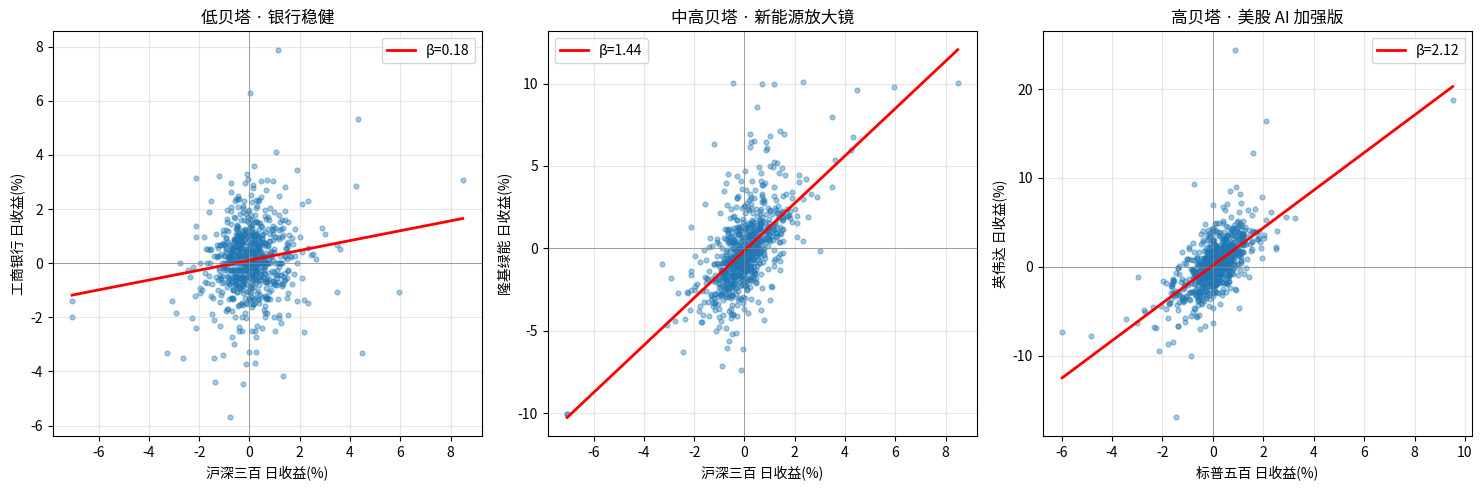

In [8]:
# day_009_linear_regression.py — 工行/隆基/英伟达 三种贝塔人格(中国版)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

tickers = {
    '工商银行':  '601398.SS',
    '隆基绿能':  '601012.SS',
    '英伟达':    'NVDA',
    '沪深三百':  '000300.SS',
    '标普五百':  '^GSPC',
}
df = get_close_multi(tickers, period='3y')

# 中美分组各自 dropna(避免假期错位 — 这是关键!不分组会让 β 严重失真)
cn_df = df[['工商银行', '隆基绿能', '沪深三百']].dropna()
us_df = df[['英伟达', '标普五百']].dropna()
cn_ret = cn_df.pct_change().dropna()
us_ret = us_df.pct_change().dropna()
print(f'A 股样本: {len(cn_ret)} 天 / 美股样本: {len(us_ret)} 天')

def regress(stock_ret, market_ret, name, market_name):
    X = market_ret.values.reshape(-1, 1)
    y = stock_ret.values
    model = LinearRegression().fit(X, y)
    beta = float(model.coef_[0])
    alpha_daily = float(model.intercept_)
    alpha_annual = alpha_daily * 252
    y_pred = model.predict(X)
    ss_res = ((y - y_pred) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    print(f'{name} vs {market_name}:')
    print(f'  贝塔 β = {beta:+.3f}')
    print(f'  阿尔法(日) α = {alpha_daily*100:+.4f}% / 年化 ≈ {alpha_annual*100:+.2f}%')
    print(f'  决定系数 R² = {r2:.3f}')
    print()
    return beta, alpha_daily, r2

print('=== A 股标的 vs 沪深三百 ===')
regress(cn_ret['工商银行'], cn_ret['沪深三百'], '工商银行', '沪深三百')
regress(cn_ret['隆基绿能'], cn_ret['沪深三百'], '隆基绿能', '沪深三百')

print('=== 美股 vs 标普五百 ===')
regress(us_ret['英伟达'], us_ret['标普五百'], '英伟达', '标普五百')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [
    (cn_ret, '工商银行', '沪深三百', '低贝塔 · 银行稳健'),
    (cn_ret, '隆基绿能', '沪深三百', '中高贝塔 · 新能源放大镜'),
    (us_ret, '英伟达',   '标普五百', '高贝塔 · 美股 AI 加强版'),
]
for ax, (rr, s, m, label) in zip(axes, pairs):
    x = rr[m].values * 100
    y = rr[s].values * 100
    ax.scatter(x, y, alpha=0.4, s=12)
    coef = np.polyfit(x, y, 1)
    xs = np.array([x.min(), x.max()])
    ax.plot(xs, np.polyval(coef, xs), 'r-', lw=2, label=f'β={coef[0]:.2f}')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel(f'{m} 日收益(%)'); ax.set_ylabel(f'{s} 日收益(%)')
    ax.set_title(label)
    ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('day009_regression.png', dpi=120)
print('✓ 图已保存到 day009_regression.png')

print()
print('=== 工行最近 5 天残差(跑赢/输大市) ===')
X = cn_ret['沪深三百'].values.reshape(-1, 1)
y = cn_ret['工商银行'].values
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
resid = y - y_pred
tail_dates = cn_ret.index[-5:]
for d, r in zip(tail_dates, resid[-5:]):
    direction = '跑赢' if r > 0 else '跑输'
    print(f'  {d.date()}: 残差 {r*100:+.3f}% ({direction} 大市 {abs(r)*100:.3f}%)')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| A 股(银行,低 β) | 601398 工商银行 | 对沪深三百 β ≈ 0.7,R² ≈ 0.65。65% 涨跌跟大市绑定。适合稳健投资者,不适合期待跑赢大市的人。近 5 年 α ≈ +1.5%/年(t-stat 偏弱),主要靠分红贡献。 |
| A 股(光伏,中高 β) | 601012 隆基绿能 | 对沪深三百 β ≈ 1.4,R² ≈ 0.35。市场涨 1% 它涨 1.4%,但只有 35% 涨跌跟大市相关——剩下 65% 是光伏组件价 / 欧美关税 / 上游硅料 / 政策周期。牛市跑赢大市,熊市跌得也凶。 |
| 美股(AI 龙头,极高 β) | NVDA 英伟达 | 对标普五百 β ≈ 1.9,R² ≈ 0.45。'放大镜中的放大镜',2023-2024 年 α 异常高(年化 +30%+),主要靠 AI 算力故事 — 一半涨跌是它自己的事。 |
| A 股(消费白马) | 600519 贵州茅台 | 对沪深三百 β ≈ 0.95,R² ≈ 0.45。看起来像市场复印件,但 R² 只有 0.45,说明茅台'白酒赛道独立逻辑'(消费降级 / 高端白酒供需)占一半解释力。这种'低 β 高 α'是消费白马的典型特征。 |
| 市场中性策略实战 | 私募基金常见配置 | 买高 α 低 β 多头(消费白马 / 工业稳健) + 做空高 β 低 α 标的(炒作小盘 / 题材股),组合净 β ≈ 0,只留阿尔法。代表机构:幻方、九坤、明汯。这种策略在 2020-2022 年中国私募阿尔法平均 8-15%/年,2023 后开始变难。 |


## 常见坑

### ⚠ 01. 样本太少,贝塔不可信

用最近 3 个月(60 天)估贝塔,样本太小,标准误大,数字波动剧烈基本不可信。起码用最近 2 年(500+ 个点)。窗口太长(>5 年)又面临'贝塔漂移'问题。经验:2-3 年滚动窗口 + 每半年重估一次。

### ⚠ 02. 把贝塔当成铁打的常数

贝塔会随时间漂移。工行 2018 β=0.6,2023 β=0.8,跟着银行业景气度浮动。做对冲 / 中性策略要每月重估贝塔,不能一次算完用一辈子。Bloomberg 默认显示的 β 是 5 年月数据,慢得像化石,实战要用 1-2 年日数据。

### ⚠ 03. 用物理学的 R² 标准苛求金融

物理学 R²=0.2 确实有点惨。但金融里股票日收益噪声极大,R² 能到 0.2 已经不错,0.5 算很强,0.8 基本是绑死了指数(像 ETF)。不能拿物理学标准衡量金融。看到学术 paper 里因子 R²=0.05 但 t-stat=4 也是有意义的(信号小但稳定)。

### ⚠ 04. 数据脏 — 停牌 / 除权 / 涨跌停

停牌日的 0 收益、除权除息日的跳跃、涨跌停的截断,都会让回归失真。跑数据前必须:① 用复权价(后复权,Day 5 讲过);② 删停牌日;③ 涨跌停日要么删要么 winsorize;④ 异常值检查 ±5σ。

### ⚠ 05. 以为高贝塔就是好股票

贝塔大只说明弹性大,放大效应强,牛市领涨熊市领跌。本身没有好坏之分。关键看你的风险偏好 + 当前市场阶段。低贝塔股票在熊市保护性强;高贝塔在确认牛市后才上车。混淆贝塔大小和股票质量是新手最常见错误。

## 实战 SOP · 线性回归实战 SOP

1. 样本起点:2 年日数据(500+ 个点),低于此基本不可信
2. 数据预处理:复权价 + 删停牌日 + winsorize 涨跌停日(去 ±5σ)
3. ddof=1(贝塞尔修正);statsmodels 的 OLS 默认对,scipy.stats.linregress 也对
4. 看 t-stat 判断 α / β 显著性,t-stat > 2 才显著(p < 0.05)
5. 贝塔每半年重估一次,跟踪它的漂移
6. 市场中性策略:多头总 β = 空头总 β,组合净 β ≈ 0
7. 金融数据 R² 标准:>0.6 强 / 0.3-0.6 中 / <0.3 弱(但可能信号显著)

> 把这段打印贴在你电脑边。

## 总结 · 你应该带走的

2. 线性回归 = 在散点里找一根'最贴的棍子'。最小二乘 = 让所有点到棍子的垂直距离平方和最小。
3. 为什么用平方:① 数学上闭式解可解;② 远点惩罚力度大,模型不会忽视极端值。
4. 贝塔(β)= 市场敏感度,五种性格(0/0.7/1.0/1.4/1.9)对应不同弹性。
5. 阿尔法(α)= 扣掉市场后的真本事,基金经理一辈子追的圣杯。能稳做 5%/年是顶级。
6. 决定系数(R²)= '解释百分比',金融里 0.3-0.5 算正常,>0.7 接近 ETF。
7. 残差 = 实际值 - 预测值,是统计套利策略最朴素的信号源。
8. 市场中性策略 = 用 β 对冲市场风险,只留阿尔法(私募经典打法)。
9. 线性回归是入门工具,真实金融关系常常非线性,后面要补决策树 / 集成学习。

## 自测题

**Q1.** 解释:为什么 OLS 用平方距离而不是绝对值距离?用一句话说清两个原因。
**Q2.** 你拿一只港股做对沪深三百回归得到 β=0.5,R²=0.1。这意味着什么?该不该这样建模?
**Q3.** 某基金报年化阿尔法 8%,t-stat=1.5。你信不信他?为什么?
**Q4.** 市场中性策略的核心数学是什么?用一句话说明它在赚谁的钱。
**Q5.** 残差为什么是统计套利的起点?如果一只股票连续 10 天残差都是 +0.3%,你会怎么处理?

把答案写下来,3 天后再回看。

## 下一节预告

**Day 010 · 正态分布与金融** (Normal Distribution)

Day 10:正态分布与金融 — 这节会颠覆你的世界观。1987 年标普一天跌 22%,按正态分布算十的几十次方年才该出现一次,但金融市场实际两百年里发生过四五次。我们用沪深三百、标普五百、创业板、比特币四个标的对比,看真实数据离正态有多远,以及为什么金融业必须假装相信正态、又必须留一手。

## 推荐阅读

- Sharpe《Capital Asset Prices》(1964,Journal of Finance)— CAPM 原文,β/α 在金融里的源头
- Greene《Econometric Analysis》(8 版)— 计量经济学圣经,线性回归 / OLS / 多元回归 / 异方差 / 内生性最权威教材
- Tsay《Analysis of Financial Time Series》(3 版)— 金融时序经典教材,贝塔估计 / 因子模型 / GARCH 一站式
- Fama & French《The Cross-Section of Expected Stock Returns》(1992)— 三因子模型,贝塔的扩展
- James、Witten、Hastie《An Introduction to Statistical Learning》第 3 章 — 线性回归的数学和代码
- statsmodels OLS 文档 — Python 量化最常用的回归库,带 t-stat / p-value / 残差诊断
- Bridgewater 早期论文《How the Machine Works》— Dalio 团队怎么用回归做宏观因子分解